In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from utils.kf_utils import load_custom_dataset
from utils.run_estimation import run_state_estimation
from utils.plot_data import *

In [3]:
sim_num = 3
dataset_num = 3
data = load_custom_dataset(dataset_path=Path.cwd().parent / f"custom_datasets/quad_dataset_run{dataset_num}.npz", sim_num=sim_num)

Data loaded from /home/jad/Uni/Master/semester-2/RL-IP/mpx/custom_datasets/quad_dataset_run3.npz.


In [4]:
start = 0
end = len(data["dt"])

result, kf = run_state_estimation(dt=data["dt"][0],
                                  init_pos=data["base_pos"][0],
                                  base_orient=data["base_orient"], # measurement
                                  base_ang_vel=data["base_ang_vel"], # measurement
                                  joint_pos=data["joint_pos"],
                                  joint_vel=data["joint_vel"],
                                  joint_acc=data["joint_acc"],
                                  contact_states=data["contact_states"],
                                  joint_torque=data["joint_torque"],
                                  Q=0.002,
                                  R=0.01)

/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Running state estimation: 100%|██████████| 5000/5000 [00:28<00:00, 177.38it/s]


### Contact force

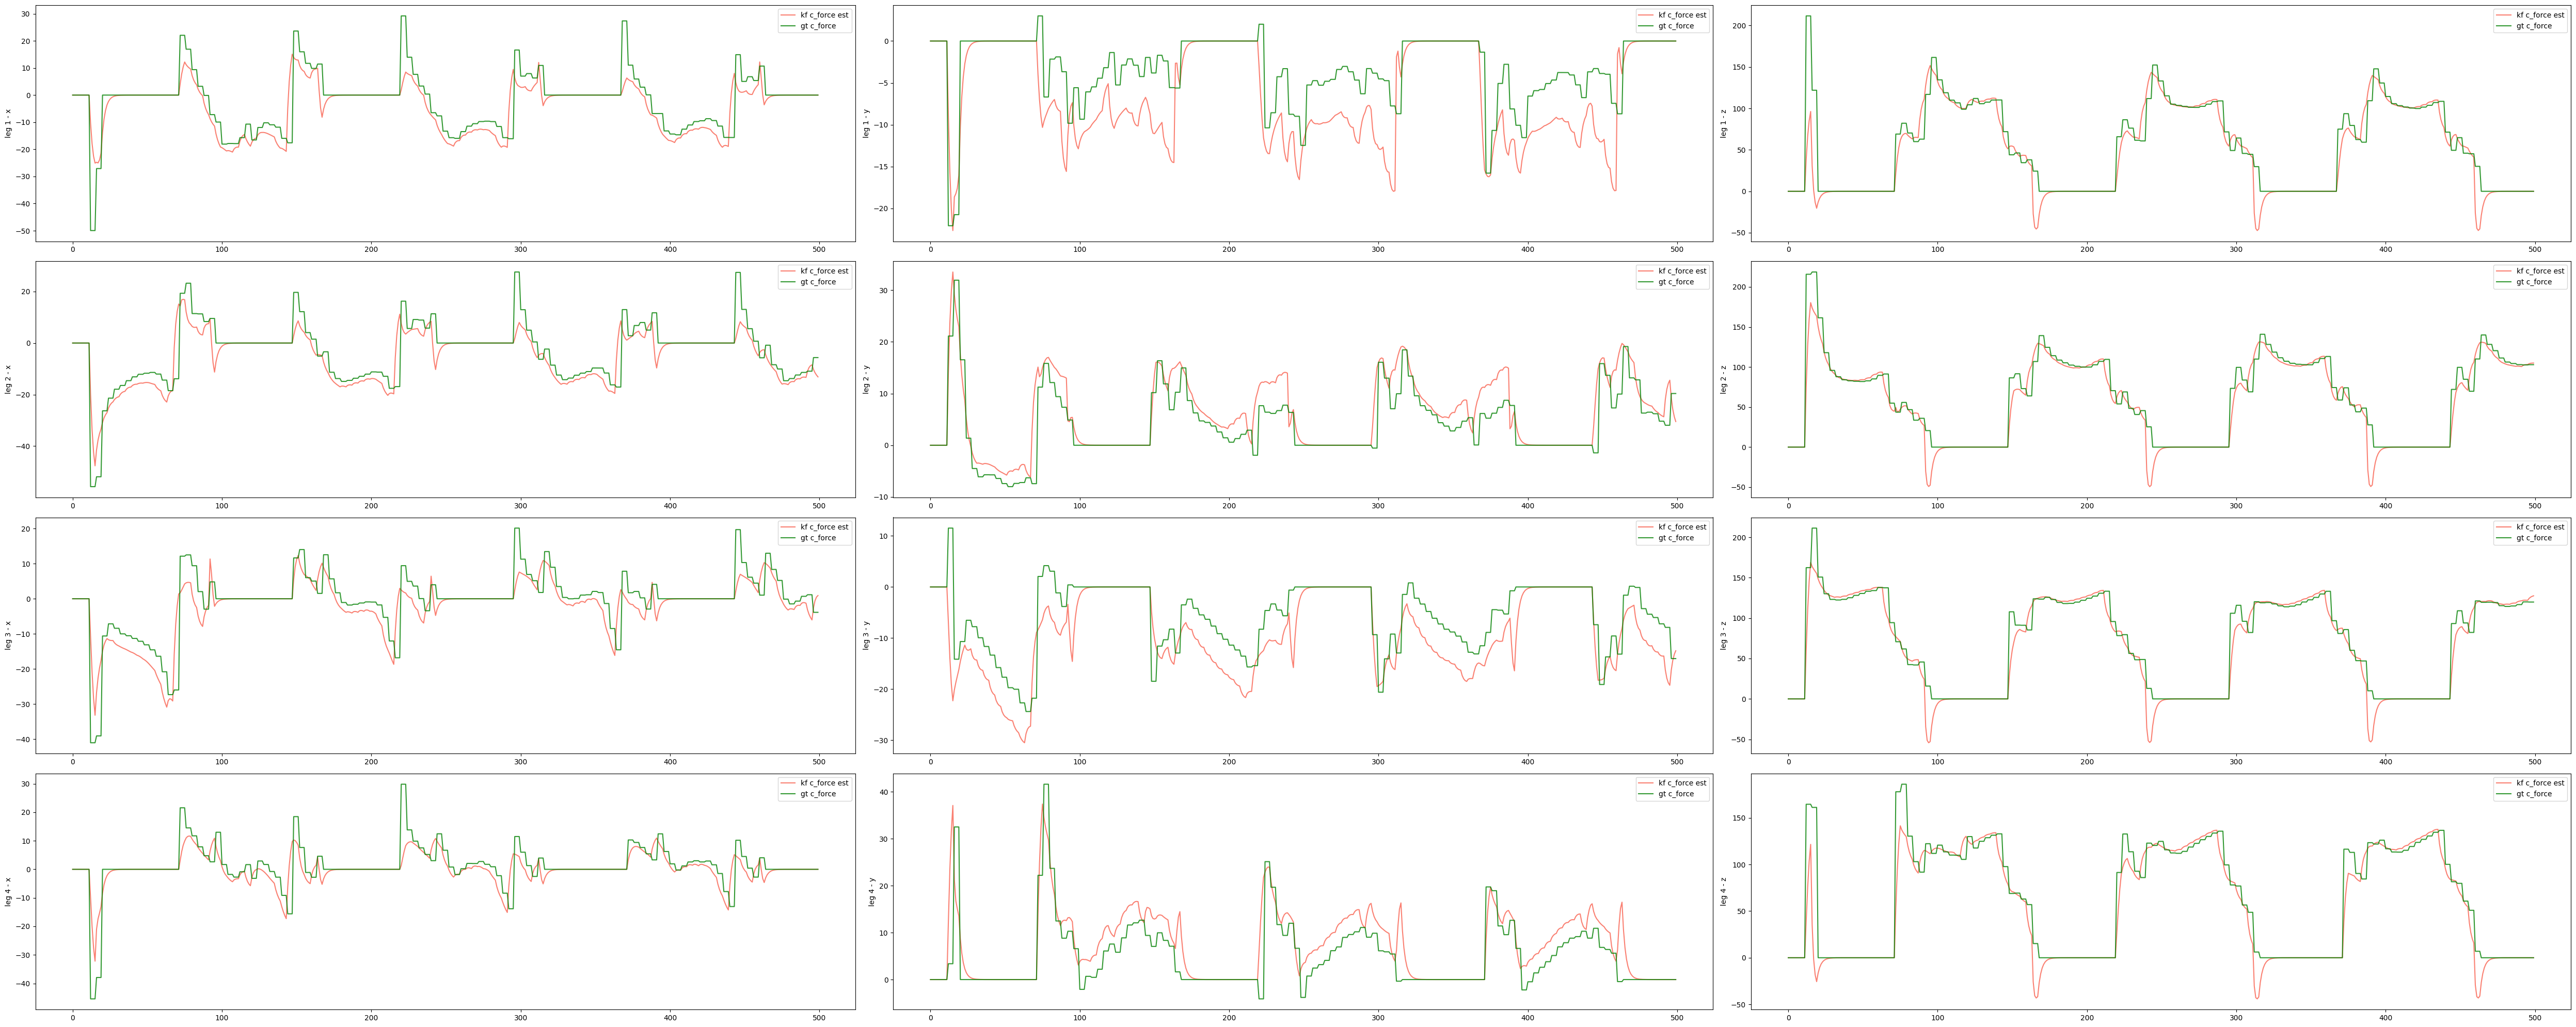

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(50,20))

gt_orient = data["contact_forces"]
c_force_est = result["c_force_update"]
num_point = 500

leg_labels = np.arange(start=1, stop=5)
force_labels = ['x', 'y', 'z']
for i in range(4):
    for j in range(3):
        axes[i, j].plot(np.arange(num_point), c_force_est[:num_point, i, j], label="kf c_force est", color="salmon")
        axes[i, j].plot(np.arange(num_point), gt_orient[:num_point, i, j], label="gt c_force", alpha=0.8, color="green")
        axes[i, j].set_ylabel(f'leg {leg_labels[i]} - {force_labels[j]}')
        axes[i, j].legend()

plt.tight_layout()
plt.show()

### Contact force coupling comparison

Compare different ways of coupling contact force into the filter:
- `dynamics` (previous/default): mass-matrix-weighted contact Jacobian
- `direct`: same geometric Jacobian, but contact force enters with coefficient 1 instead of `pinv(H_B)` ("multiplied by 1")
- `identity`: contact_state-gated identity on lin_vel only (no geometry, no mass weighting at all)
- `contact_gated` decay: same as `dynamics`, but the C_FORCE->C_FORCE block of A (bottom-right corner) decays to zero for feet not in contact, instead of persisting unchanged
- `predict only`: the filter's prediction of contact force, before the measurement update
- `observation only`: the raw J^T tau estimate that is fed into the filter as a measurement (no filtering at all)

In [5]:
result_direct, _ = run_state_estimation(dt=data["dt"][0],
                                        init_pos=data["base_pos"][0],
                                        base_orient=data["base_orient"],
                                        base_ang_vel=data["base_ang_vel"],
                                        joint_pos=data["joint_pos"],
                                        joint_vel=data["joint_vel"],
                                        joint_acc=data["joint_acc"],
                                        contact_states=data["contact_states"],
                                        joint_torque=data["joint_torque"],
                                        Q=0.002,
                                        R=0.01,
                                        contact_coupling="direct")

result_identity, _ = run_state_estimation(dt=data["dt"][0],
                                          init_pos=data["base_pos"][0],
                                          base_orient=data["base_orient"],
                                          base_ang_vel=data["base_ang_vel"],
                                          joint_pos=data["joint_pos"],
                                          joint_vel=data["joint_vel"],
                                          joint_acc=data["joint_acc"],
                                          contact_states=data["contact_states"],
                                          joint_torque=data["joint_torque"],
                                          Q=0.002,
                                          R=0.01,
                                          contact_coupling="identity")

result_gated, _ = run_state_estimation(dt=data["dt"][0],
                                       init_pos=data["base_pos"][0],
                                       base_orient=data["base_orient"],
                                       base_ang_vel=data["base_ang_vel"],
                                       joint_pos=data["joint_pos"],
                                       joint_vel=data["joint_vel"],
                                       joint_acc=data["joint_acc"],
                                       contact_states=data["contact_states"],
                                       joint_torque=data["joint_torque"],
                                       Q=0.002,
                                       R=0.01,
                                       contact_force_decay="contact_gated")

Running state estimation: 100%|██████████| 5000/5000 [00:29<00:00, 170.04it/s]


leg-axis  direct (x1, no mass weighting)identity + contact_statedynamics, contact-gated decaypredict only (no update)
1-x                  42.5410           42.4970           42.3130           36.6916
1-y                  19.1817           19.1680           19.3236           18.5532
1-z                 335.8153          335.8473          339.8165          325.4013
2-x                  30.7872           30.7957           31.3771           24.9345
2-y                  18.6151           18.5938           18.1025           16.8168
2-z                 268.2485          268.2832          276.2489          279.5957
3-x                  36.0249           36.0335           35.2944           31.0220
3-y                  17.1286           17.0178           16.5304           17.3066
3-z                 214.9155          214.9359          221.7065          251.3583
4-x                  14.6095           14.5708           14.9538           12.4282
4-y                  19.6382           19.6911      

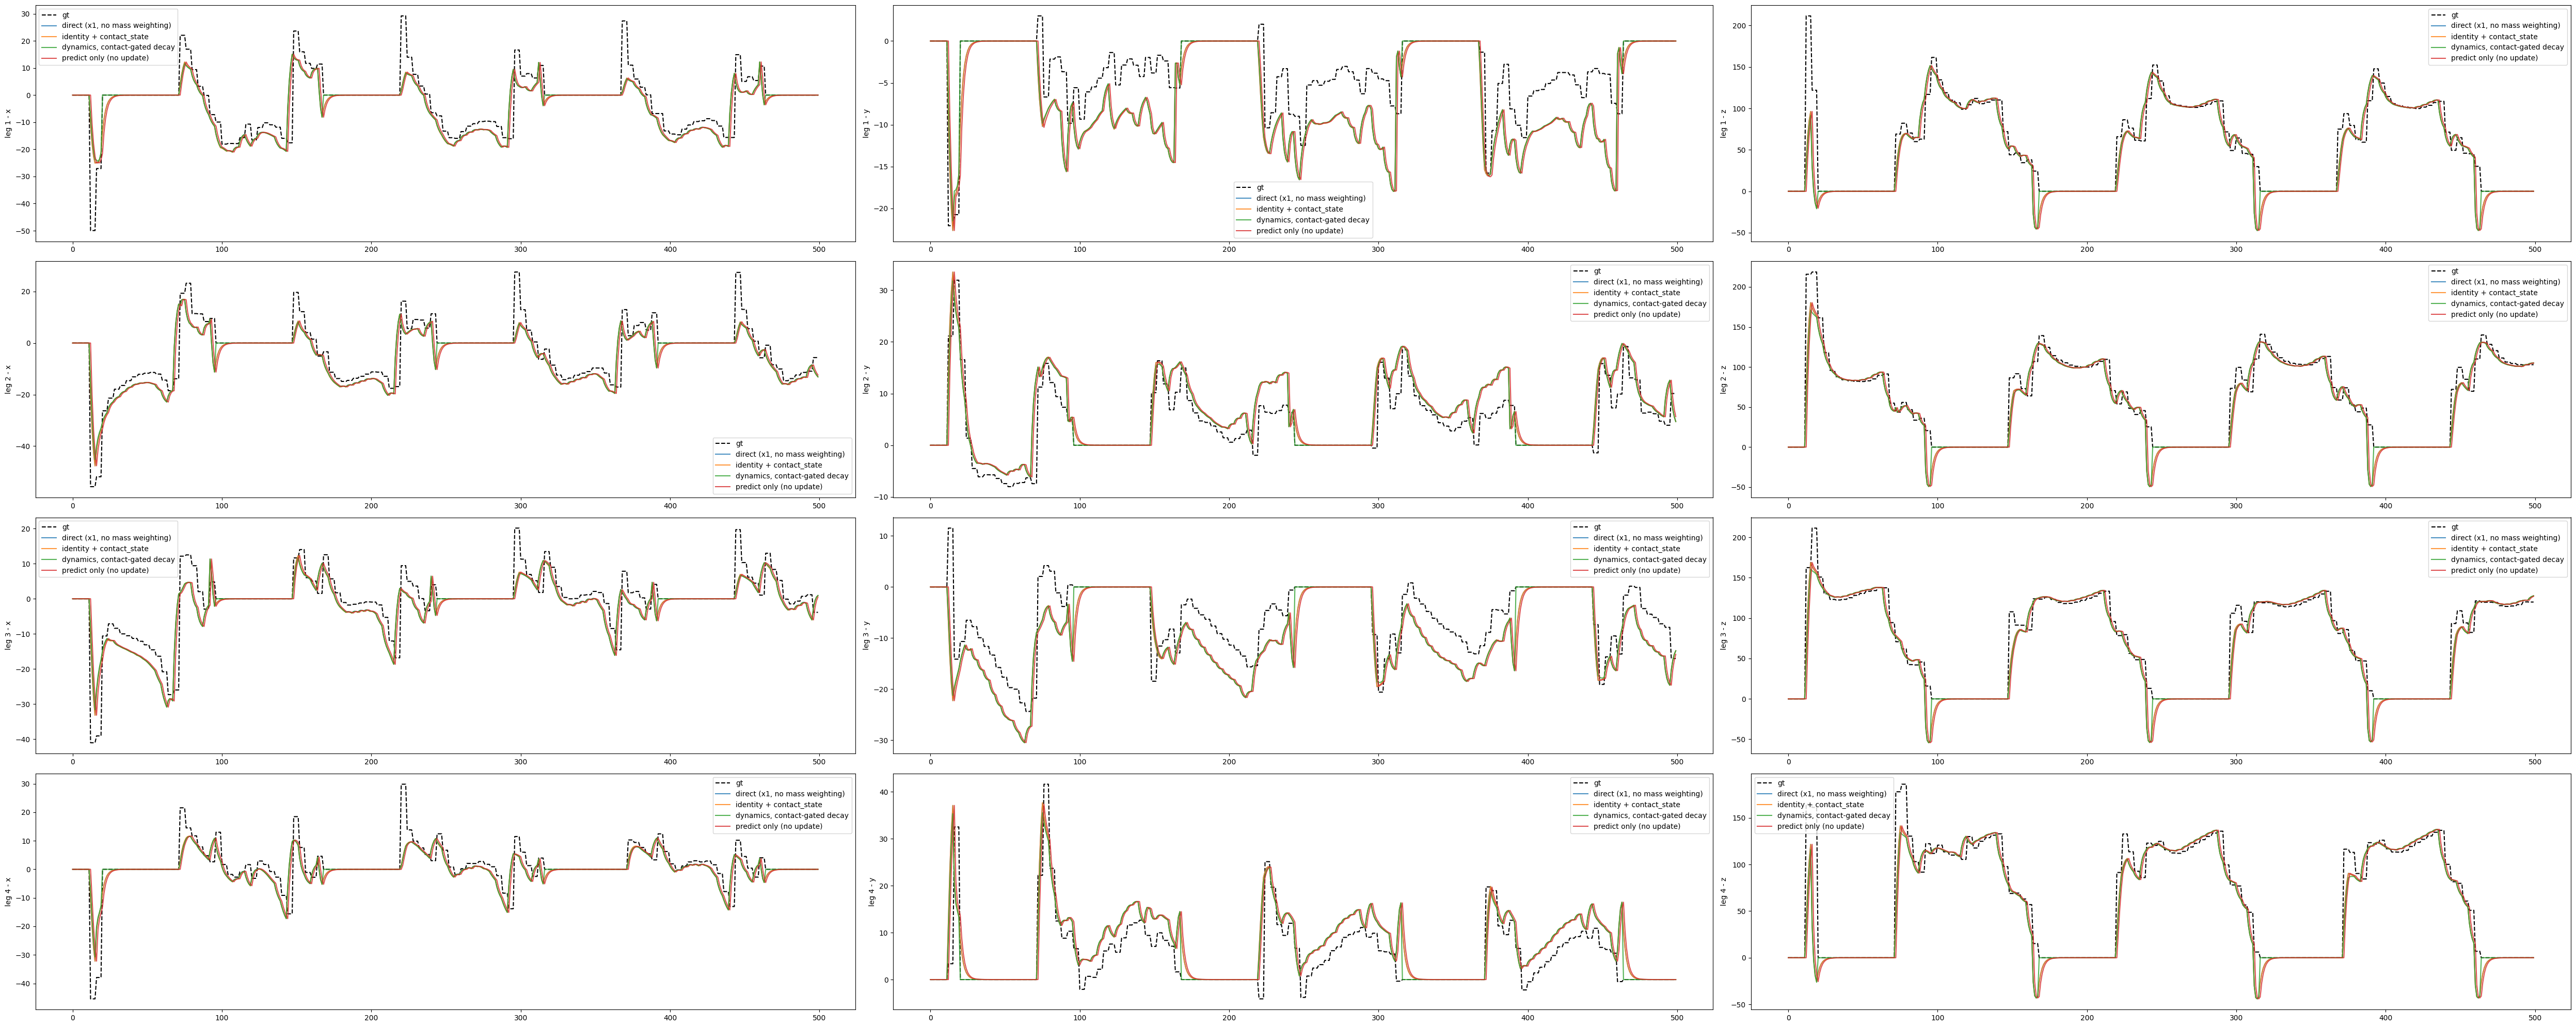

In [8]:
estimates = {
    # "dynamics (previous)": result["c_force_update"],
    "direct (x1, no mass weighting)": result_direct["c_force_update"],
    "identity + contact_state": result_identity["c_force_update"],
    "dynamics, contact-gated decay": result_gated["c_force_update"],
    "predict only (no update)": result["c_force_predict"],
    # "observation only (J^T tau)": result["c_force_obs"],
}

gt_c_force = data["contact_forces"]
mse = contact_force_mse(gt_c_force, estimates)
plot_contact_force_comparison(gt_c_force, estimates, num_point=500)

### Orientation

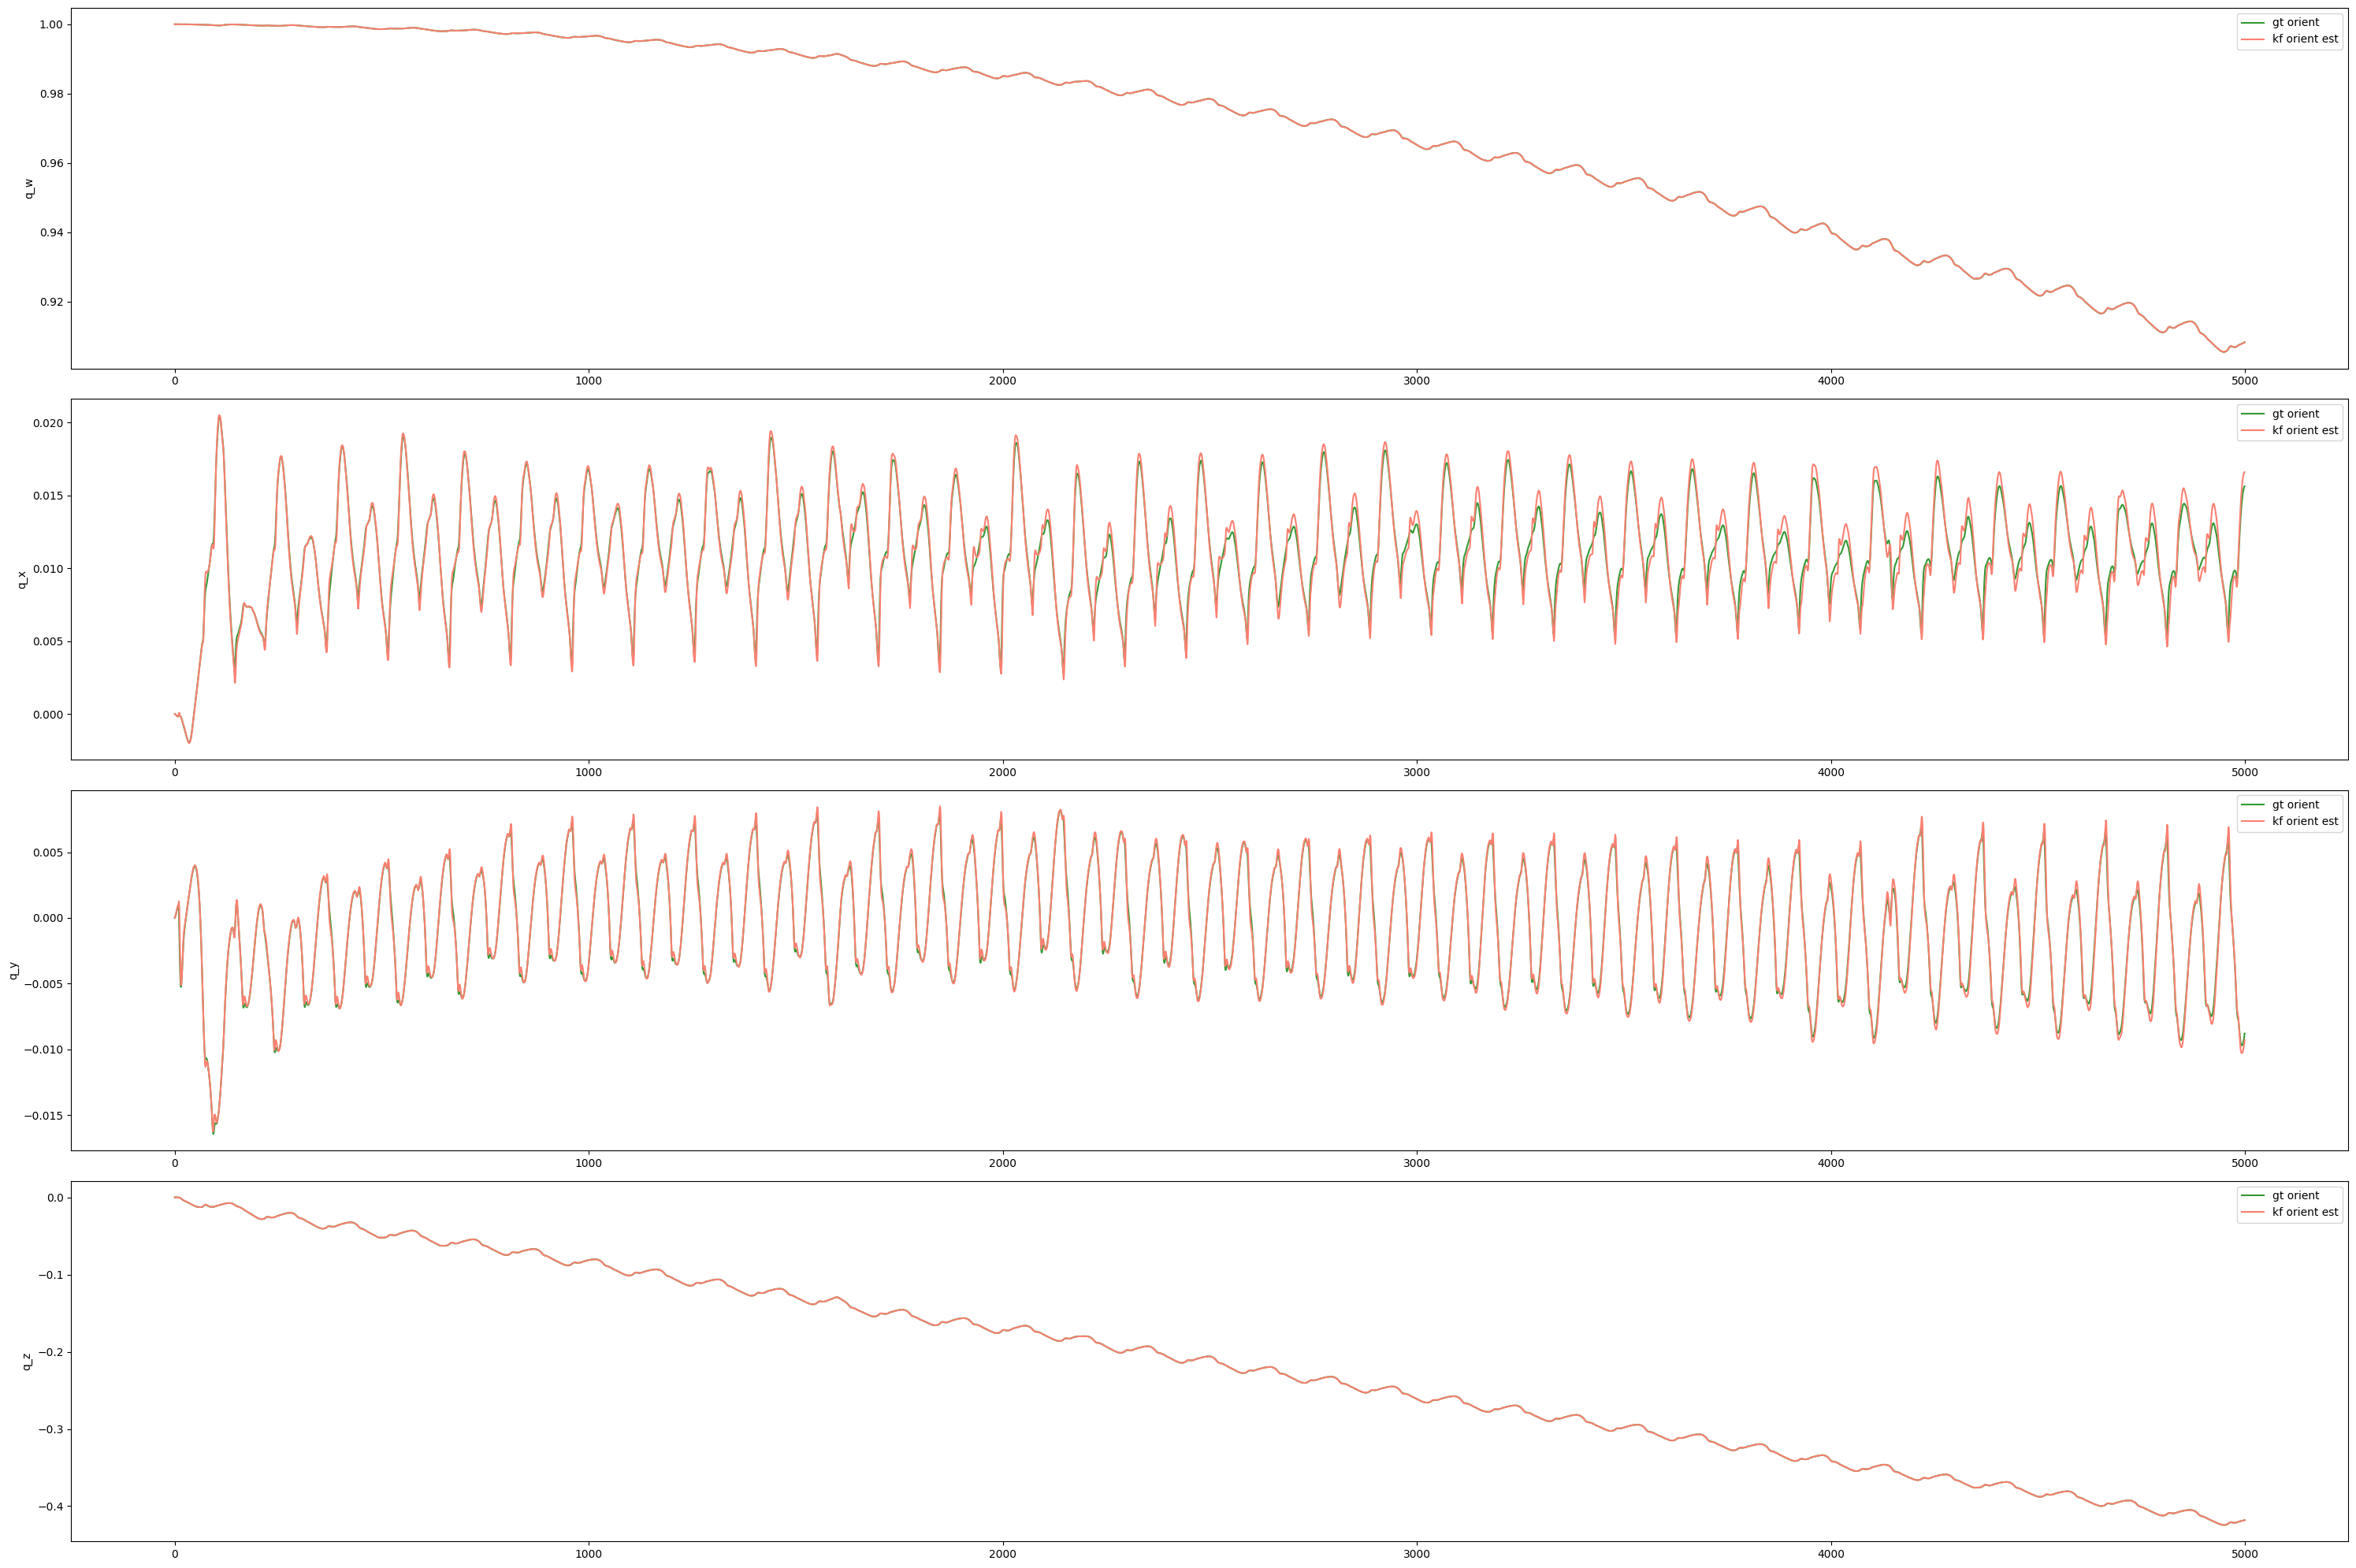

In [9]:
from utils.kf_utils import rot_to_quat

fig, axes = plt.subplots(4, 1, figsize=(30,20))

gt_orient = data["base_orient"]
orient_est = result["orient_update"]
num_point = 5000

orient_est_quat = []
for orient in orient_est:
    quat = rot_to_quat(orient)
    orient_est_quat.append(quat)
orient_est_quat = np.array(orient_est_quat)

labels = ['w', 'x', 'y', 'z']
for i in range(4):
    axes[i].plot(np.arange(num_point), gt_orient[:num_point, i], label="gt orient", alpha=0.8, color="green")
    axes[i].plot(np.arange(num_point), orient_est_quat[:num_point, i], label="kf orient est", color="salmon")
    axes[i].set_ylabel(f'q_{labels[i]}')
    axes[i].legend()

plt.tight_layout()
plt.show()

### Acceleration and angular velocity

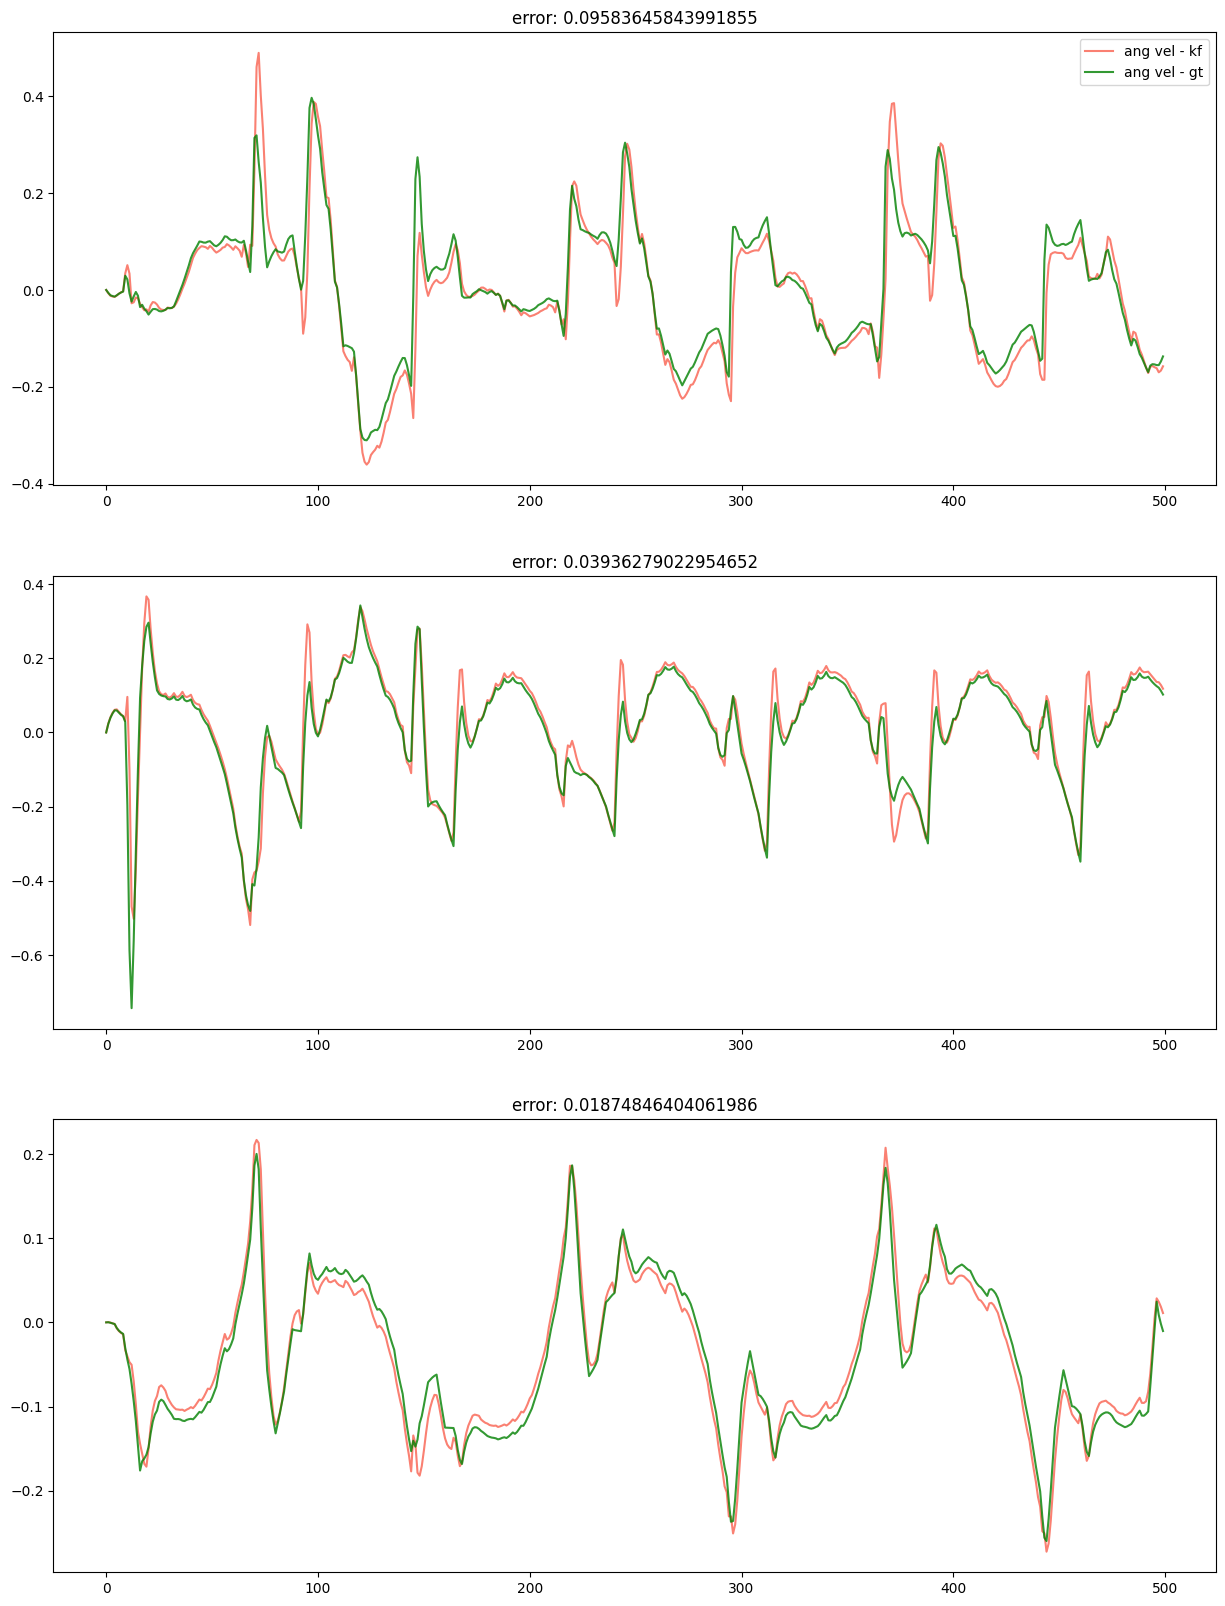

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(15,20))

gt_vel = data["base_ang_vel"]
kf_est = result["ang_vel_update"]
num_point = 500

for i in range(3):
    axes[i].plot(np.arange(num_point), kf_est[:num_point, i], label="ang vel - kf", color="salmon")
    axes[i].plot(np.arange(num_point), gt_vel[:num_point, i], label="ang vel - gt", alpha=0.8, color="green")

    error = np.sqrt(np.mean((gt_vel[:,i] - kf_est[:, i])**2, axis=0))
    axes[i].set_title(f"error: {error}")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc="upper right")

plt.show()

### Position and linear velocity

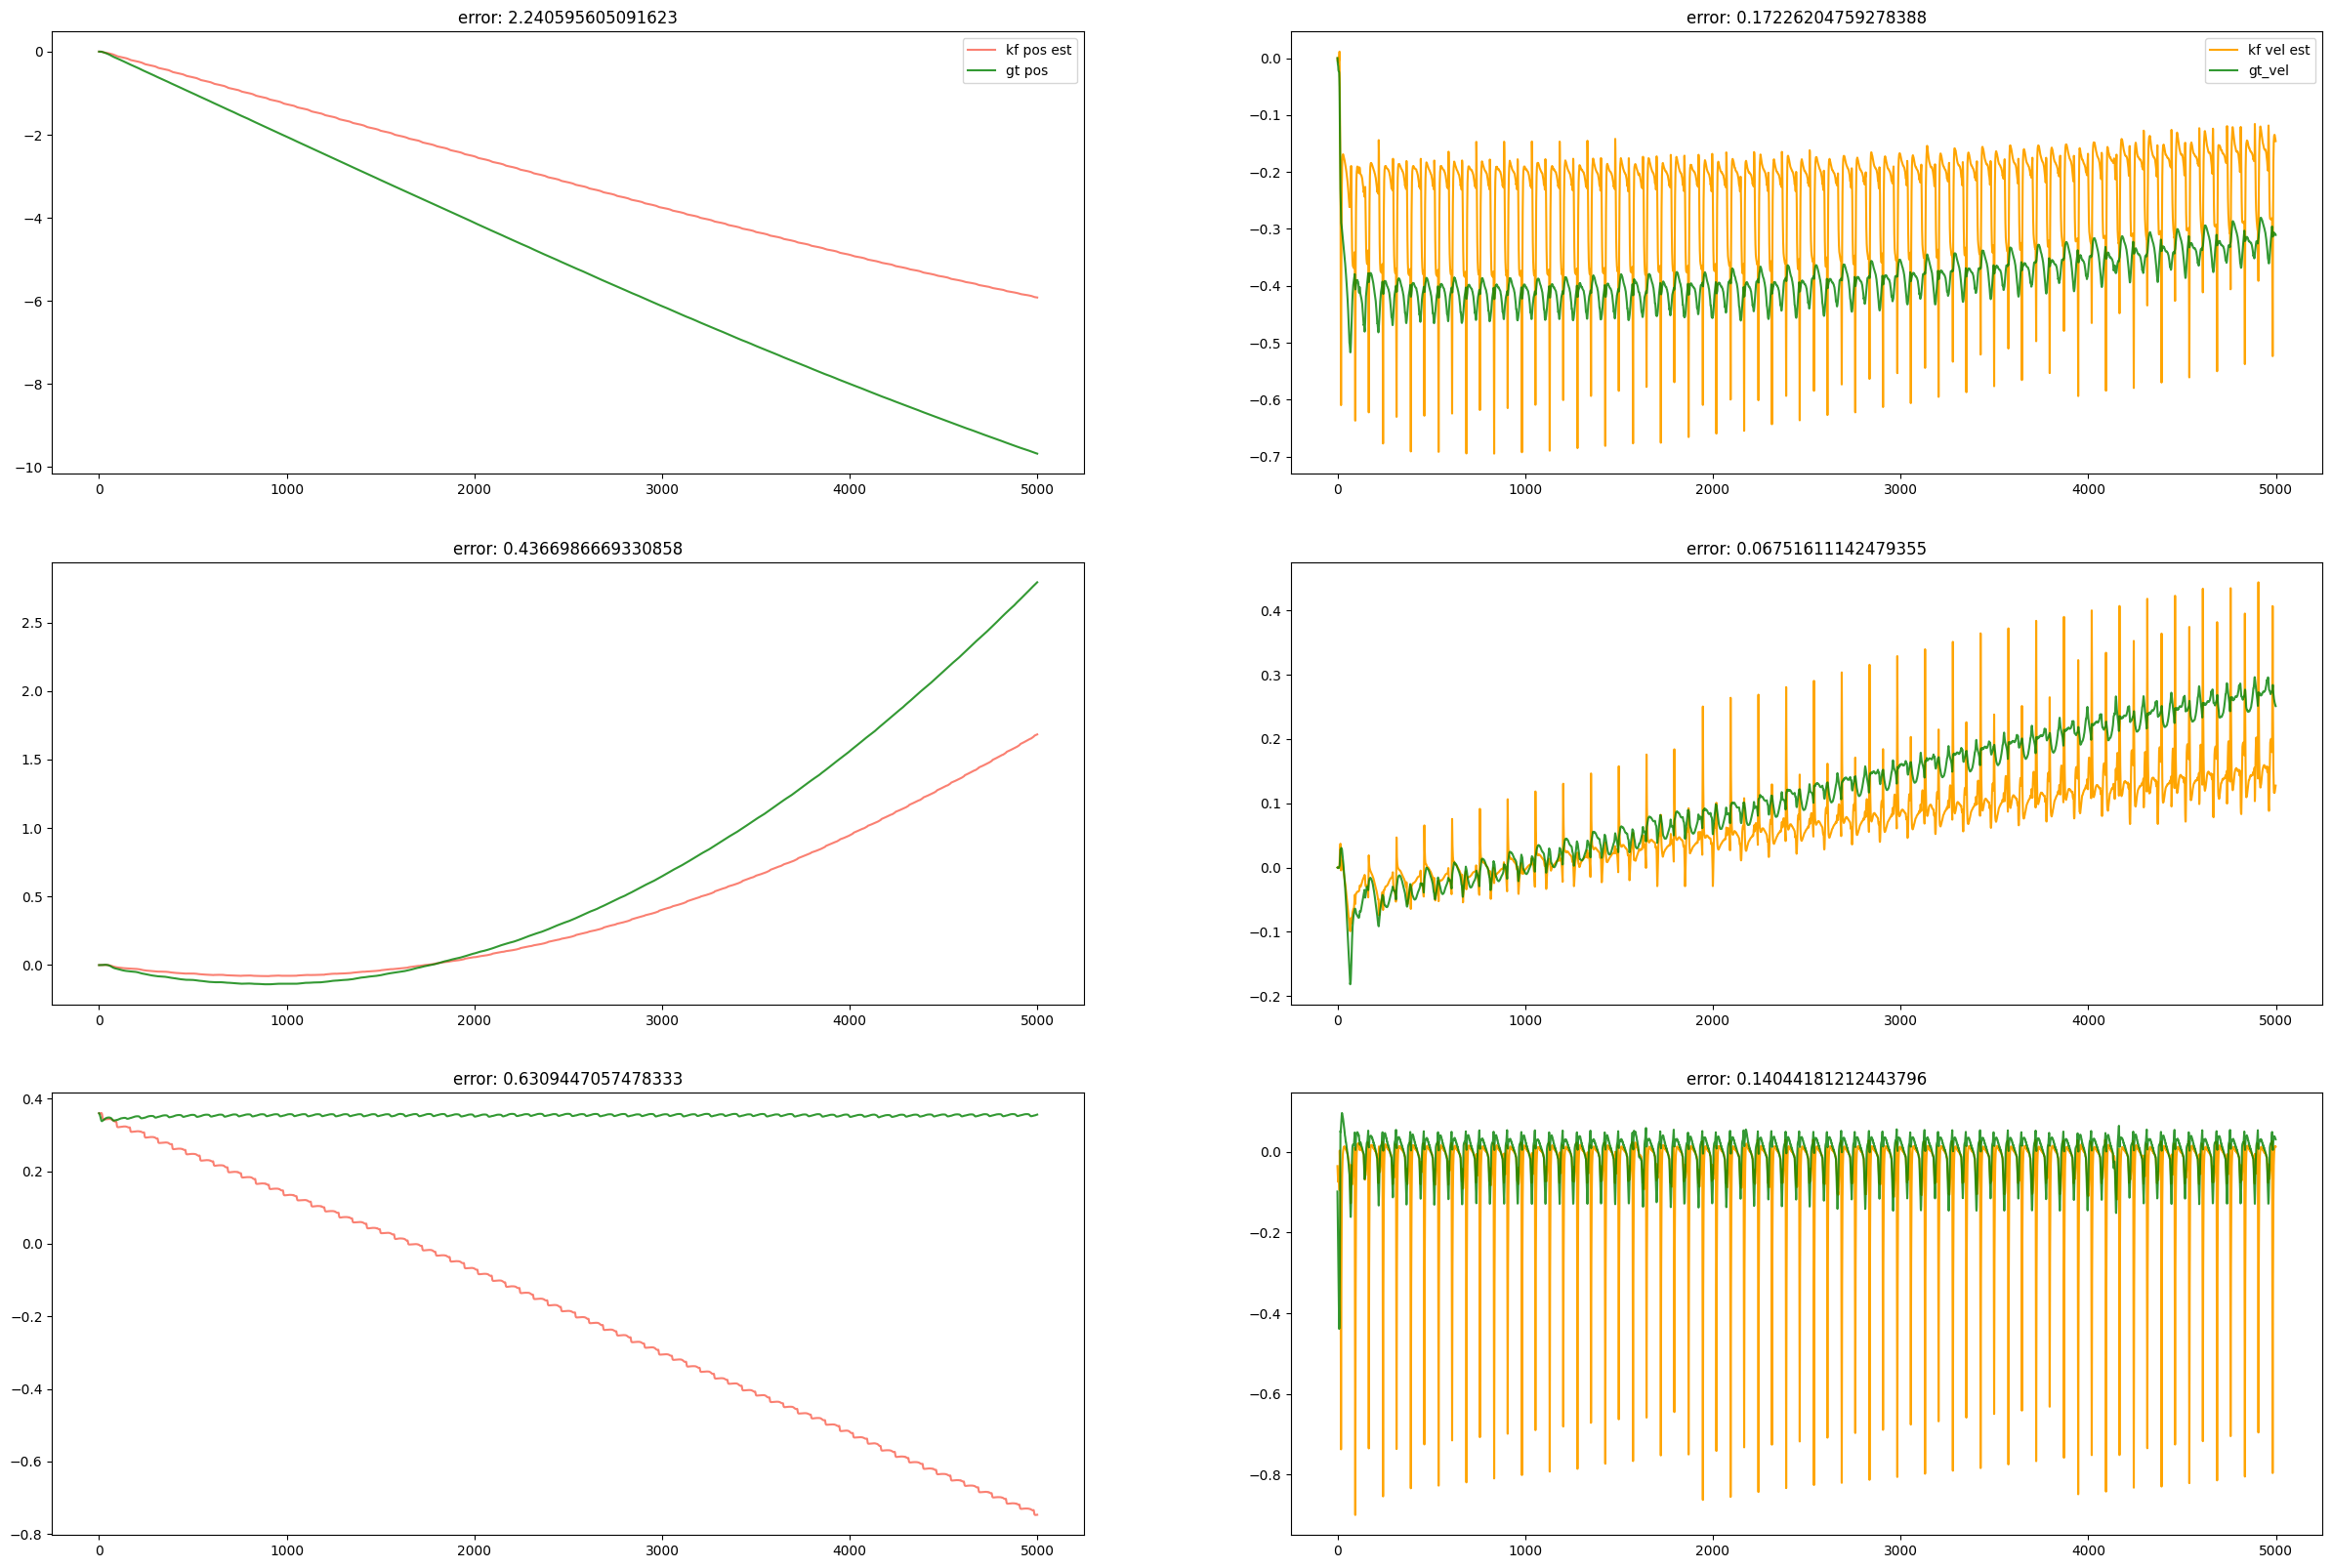

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(30,20))

gt_pos = data["base_pos"]
pos_est = result["pos_update"]
gt_vel = data["base_vel"]
vel_est = result["vel_update"]
num_point = 5000

for i in range(3):
    # plot lin acc
    axes[i][0].plot(np.arange(num_point), pos_est[:num_point, i], label="kf pos est", color="salmon")
    axes[i][0].plot(np.arange(num_point), gt_pos[:num_point, i], label="gt pos", alpha=0.8, color="green")

    # plot ang acc
    axes[i][1].plot(np.arange(num_point), vel_est[:num_point, i], label="kf vel est", color="orange")
    axes[i][1].plot(np.arange(num_point), gt_vel[:num_point, i], label="gt_vel", alpha=0.8, color="green")

    error_1 = np.sqrt(np.mean((gt_pos[:,i] - pos_est[:, i])**2, axis=0))
    error_2 = np.sqrt(np.mean((gt_vel[:,i] - vel_est[:, i])**2, axis=0))

    axes[i][0].set_title(f"error: {error_1}")
    axes[i][1].set_title(f"error: {error_2}")

for col in range(2):
    handles, labels = axes[0, col].get_legend_handles_labels()
    axes[0, col].legend(handles, labels, loc="upper right")

plt.show()

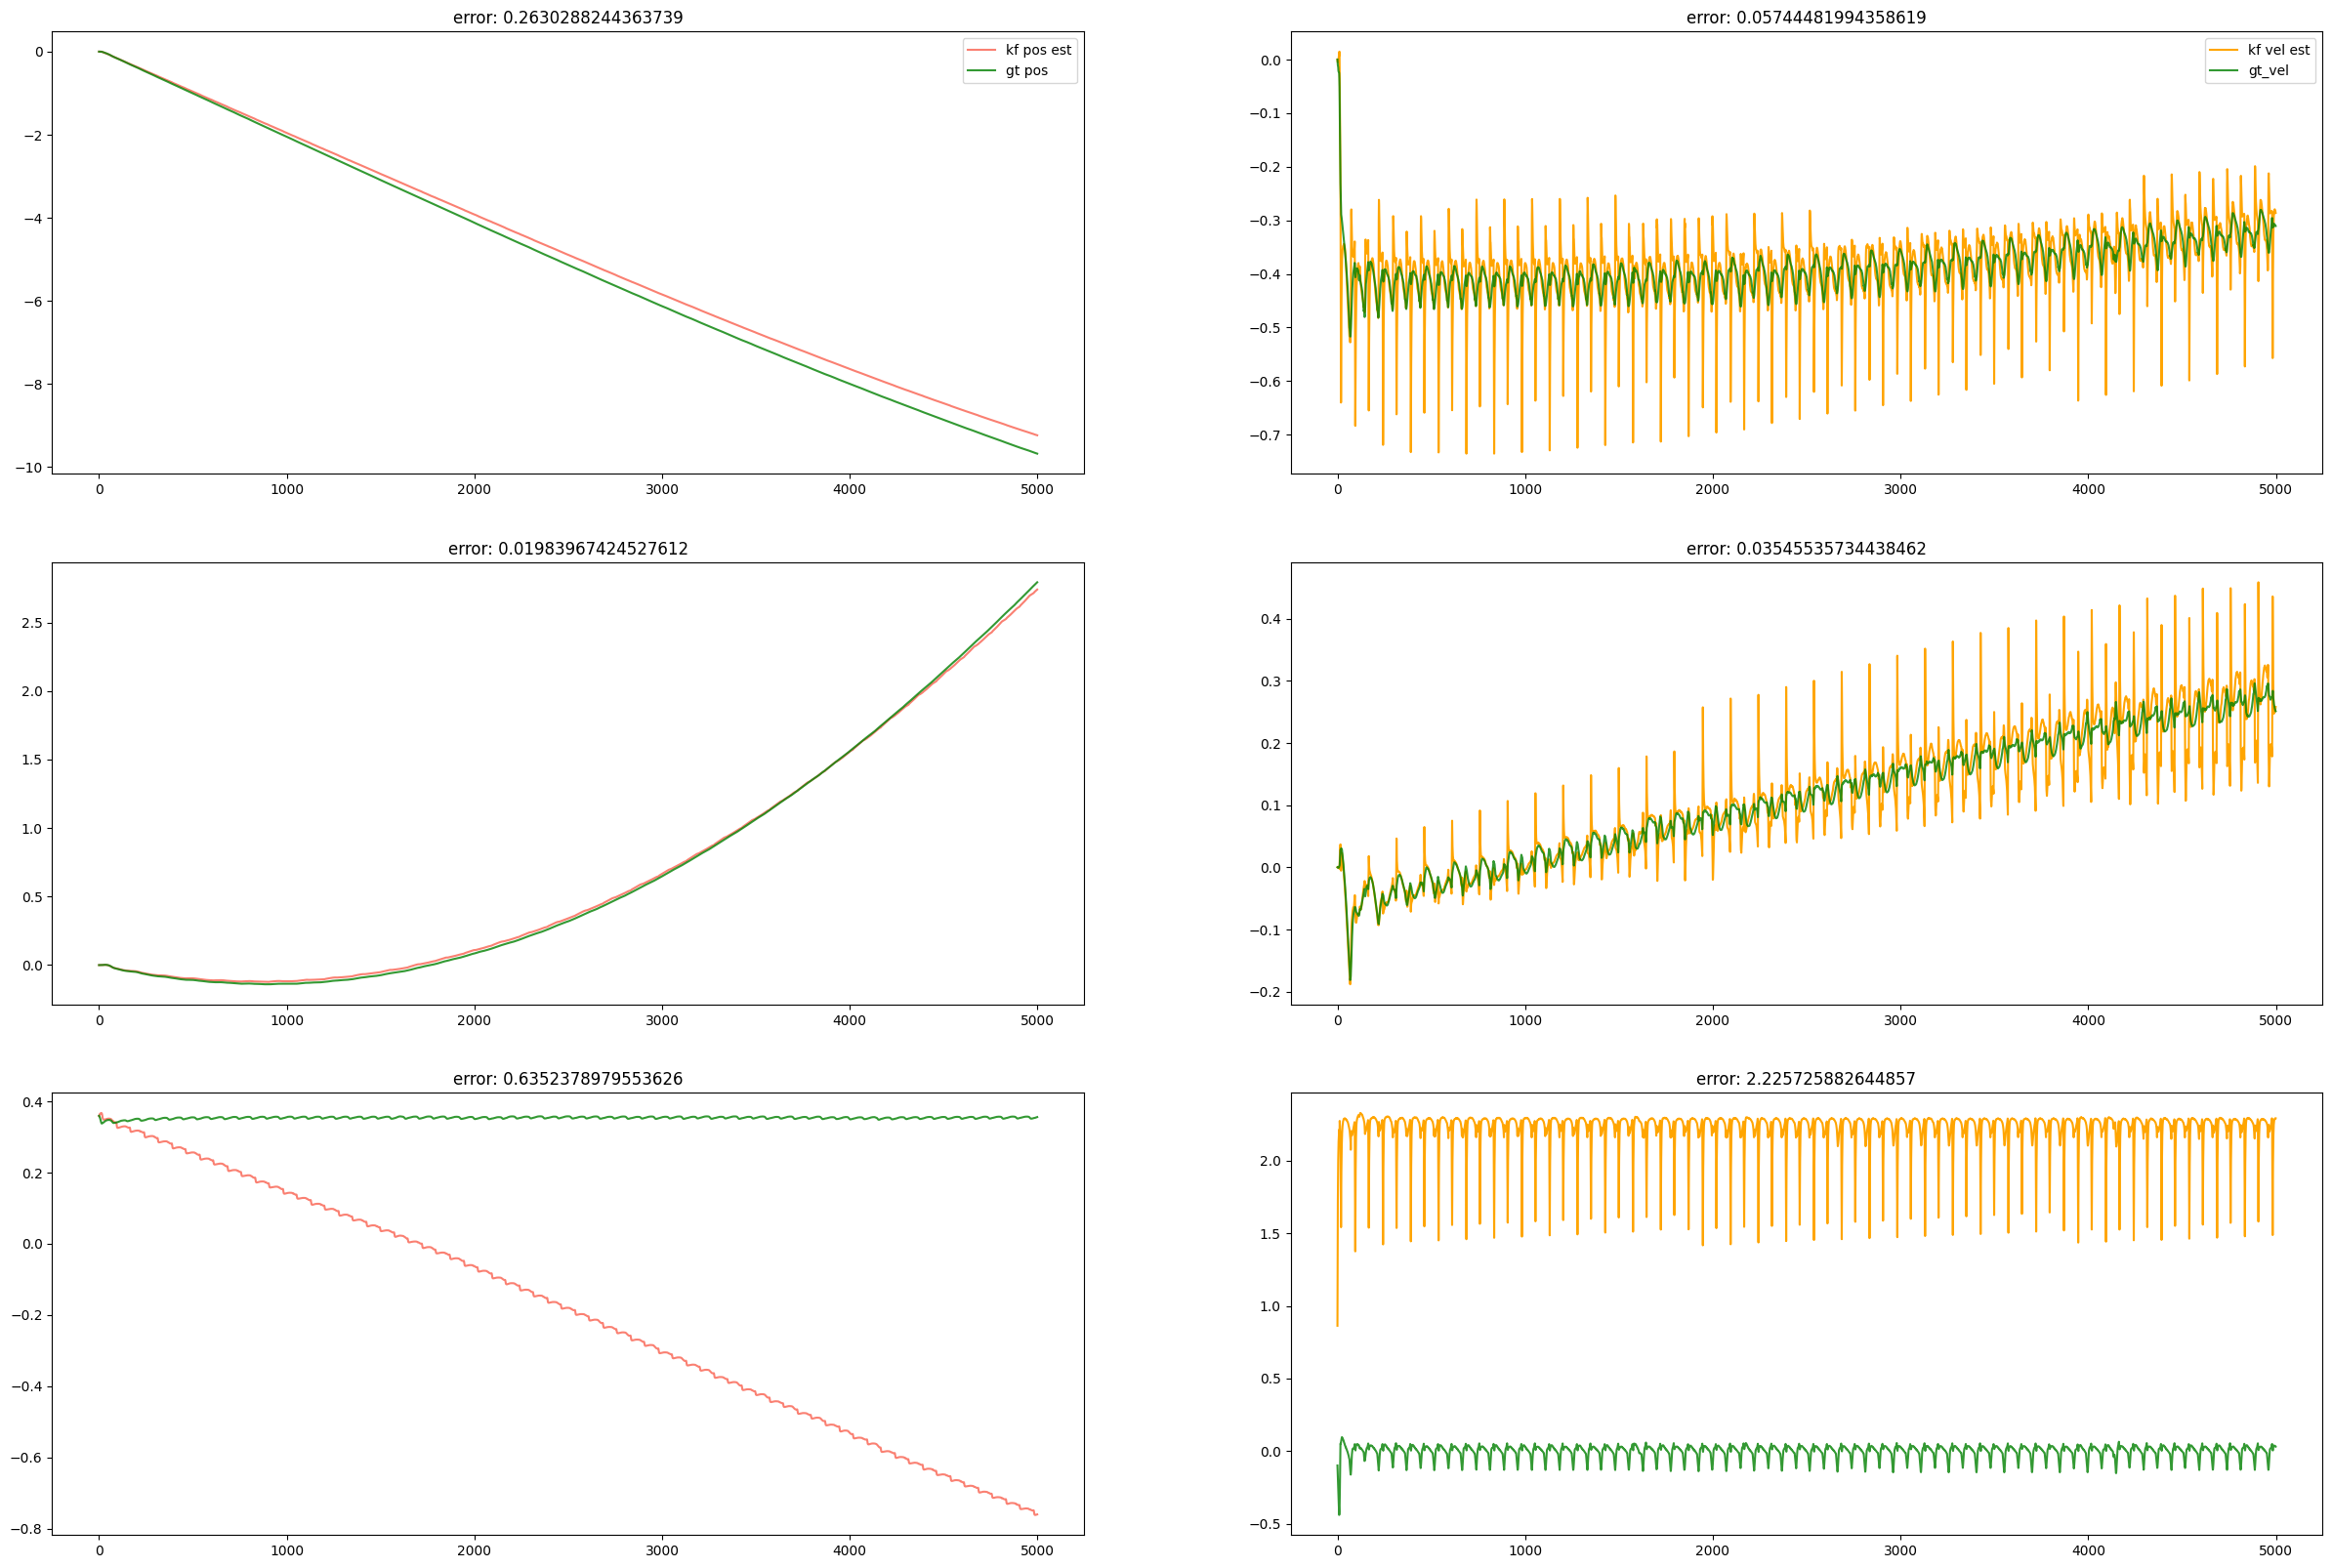

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(30,20))

gt_pos = data["base_pos"]
pos_est = result["pos_update"]
gt_vel = data["base_vel"]
vel_est = result["vel_update"]
num_point = 5000

for i in range(3):
    # plot lin acc
    axes[i][0].plot(np.arange(num_point), pos_est[:num_point, i], label="kf pos est", color="salmon")
    axes[i][0].plot(np.arange(num_point), gt_pos[:num_point, i], label="gt pos", alpha=0.8, color="green")

    # plot ang acc
    axes[i][1].plot(np.arange(num_point), vel_est[:num_point, i], label="kf vel est", color="orange")
    axes[i][1].plot(np.arange(num_point), gt_vel[:num_point, i], label="gt_vel", alpha=0.8, color="green")

    error_1 = np.sqrt(np.mean((gt_pos[:,i] - pos_est[:, i])**2, axis=0))
    error_2 = np.sqrt(np.mean((gt_vel[:,i] - vel_est[:, i])**2, axis=0))

    axes[i][0].set_title(f"error: {error_1}")
    axes[i][1].set_title(f"error: {error_2}")

for col in range(2):
    handles, labels = axes[0, col].get_legend_handles_labels()
    axes[0, col].legend(handles, labels, loc="upper right")

plt.show()

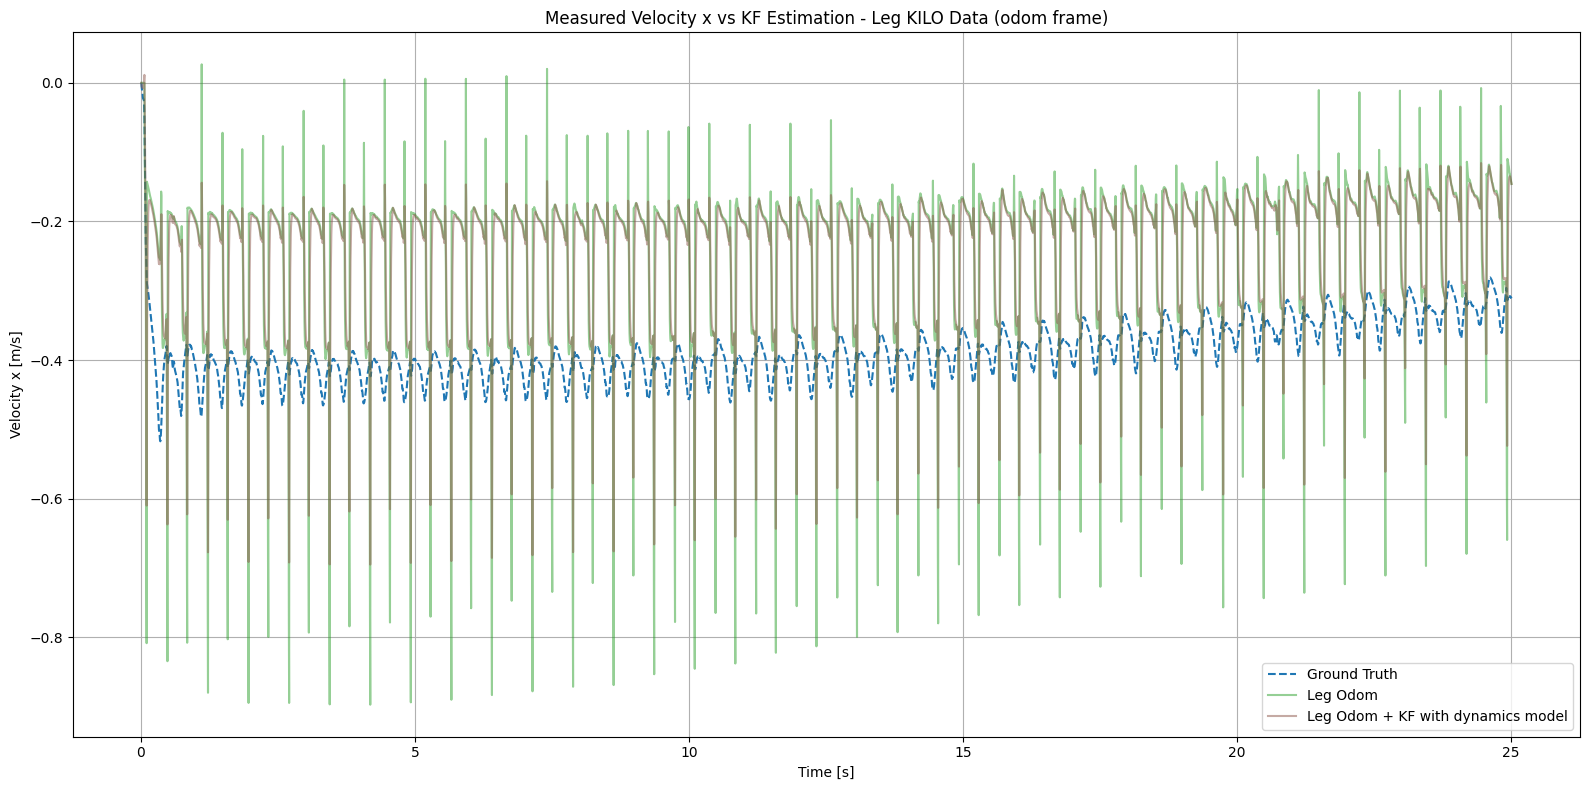

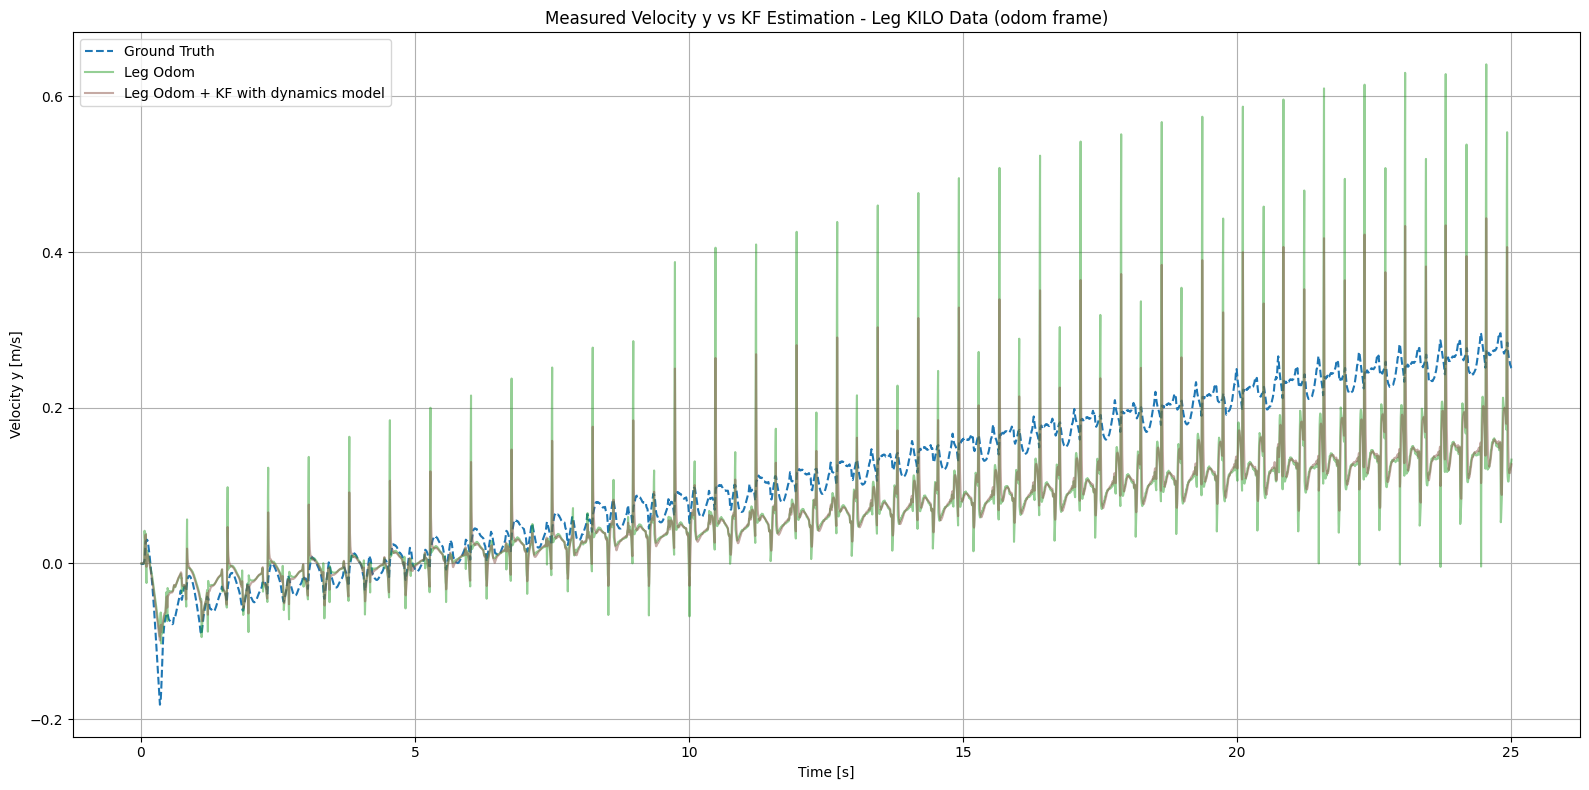

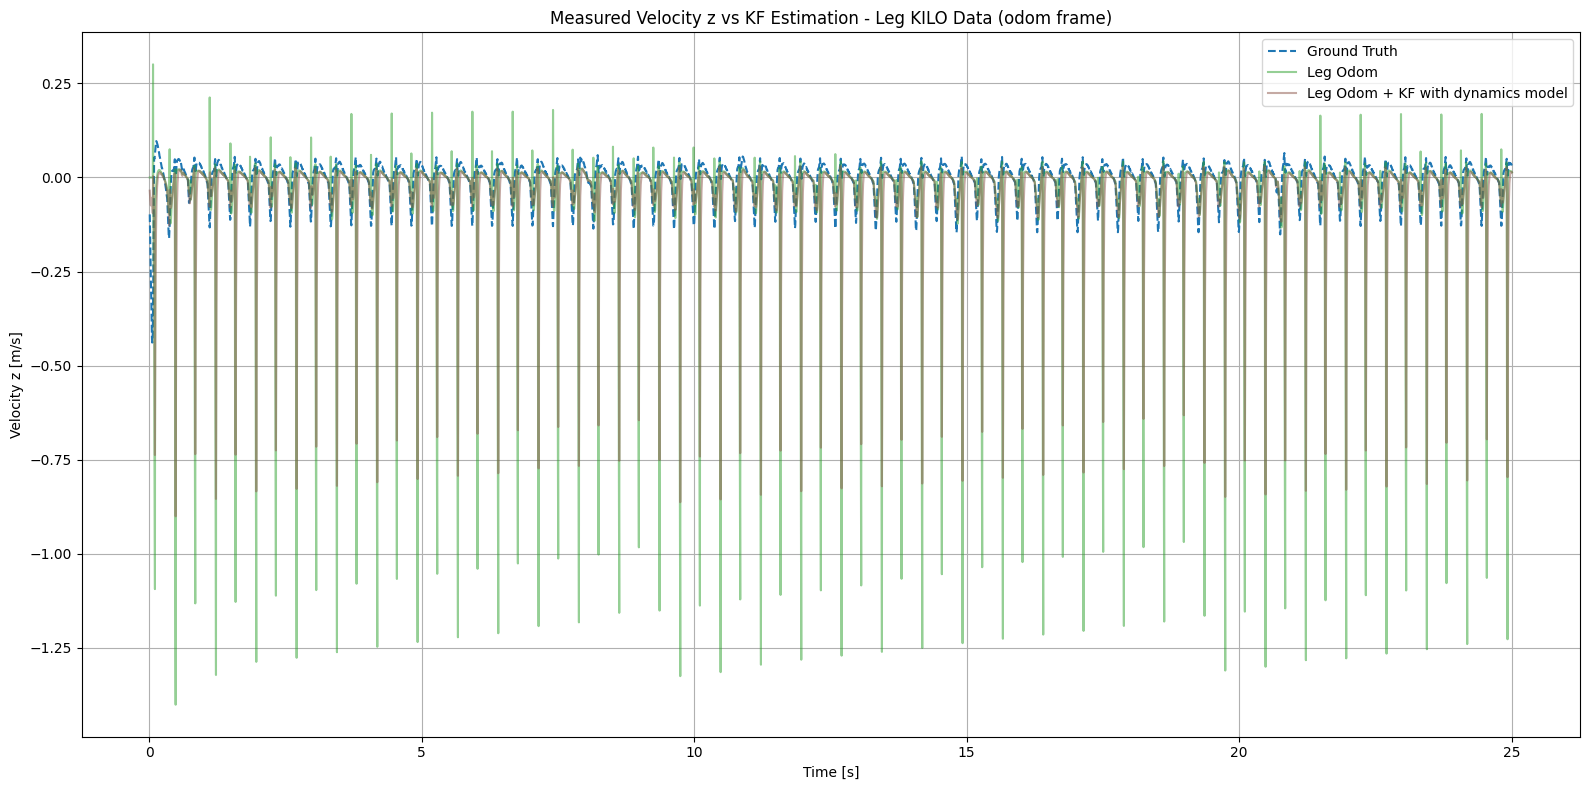

In [17]:
# Odom frame

colors = ['#1f77b4', # gt
        '#2ca02c', # leg odom
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

dim = ["x", "y", "z"]
num_data_points = len(data["dt"])

for i in range(len(dim)):
    gt_values = data["base_vel"][:num_data_points, i:i+1]

    pred_values = [result["leg_odom"][:num_data_points, i:i+1],
                   result["vel_update"][:num_data_points, i:i+1]]

    pred_labels = ["Leg Odom", "Leg Odom + KF with dynamics model"]

    compare_estimation_plot(time=data["time"][:num_data_points],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Leg KILO Data (odom frame)",
                            colors=colors
                            )

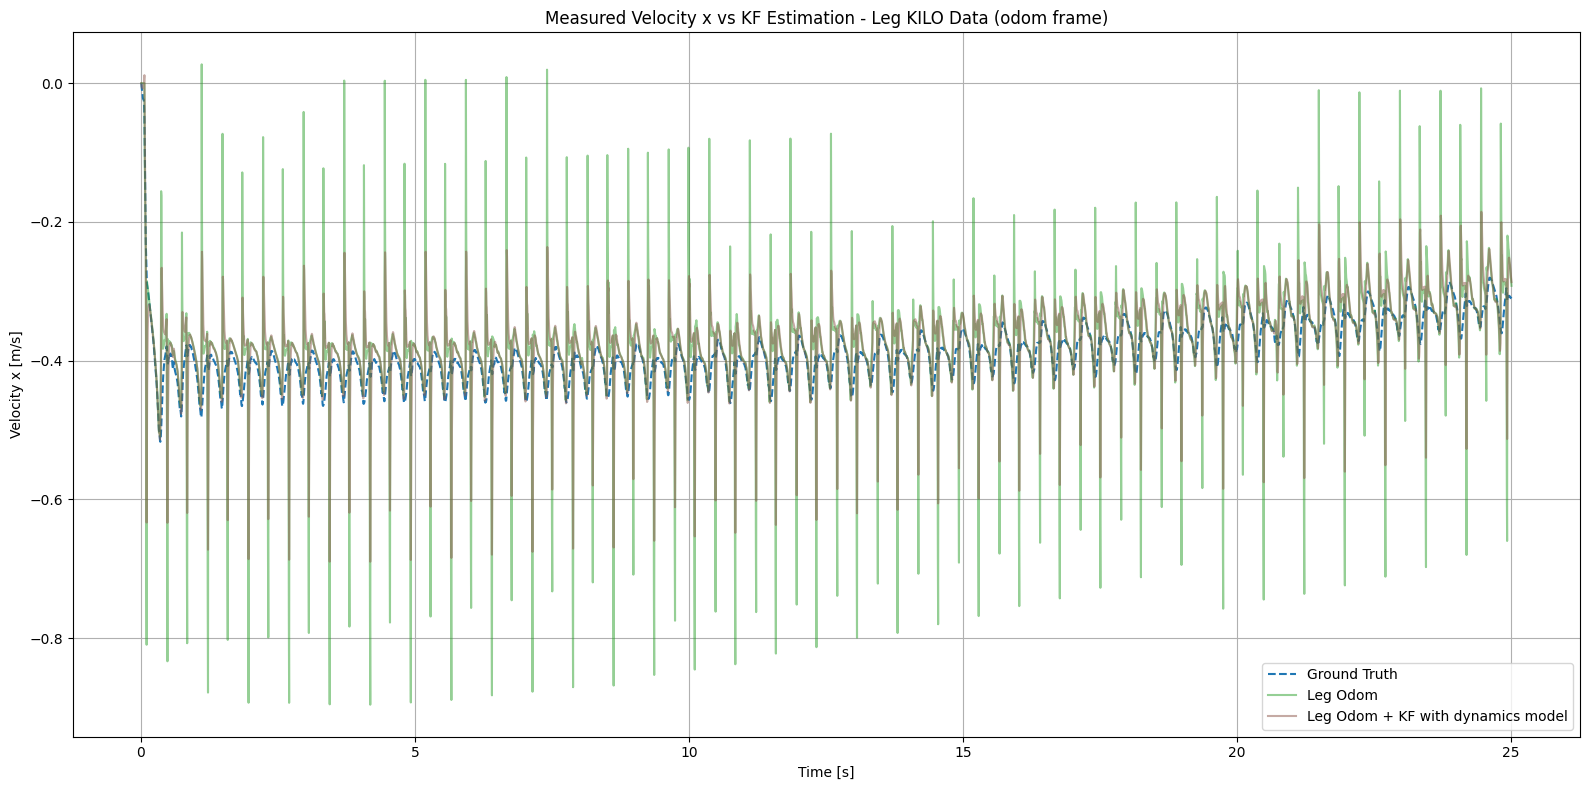

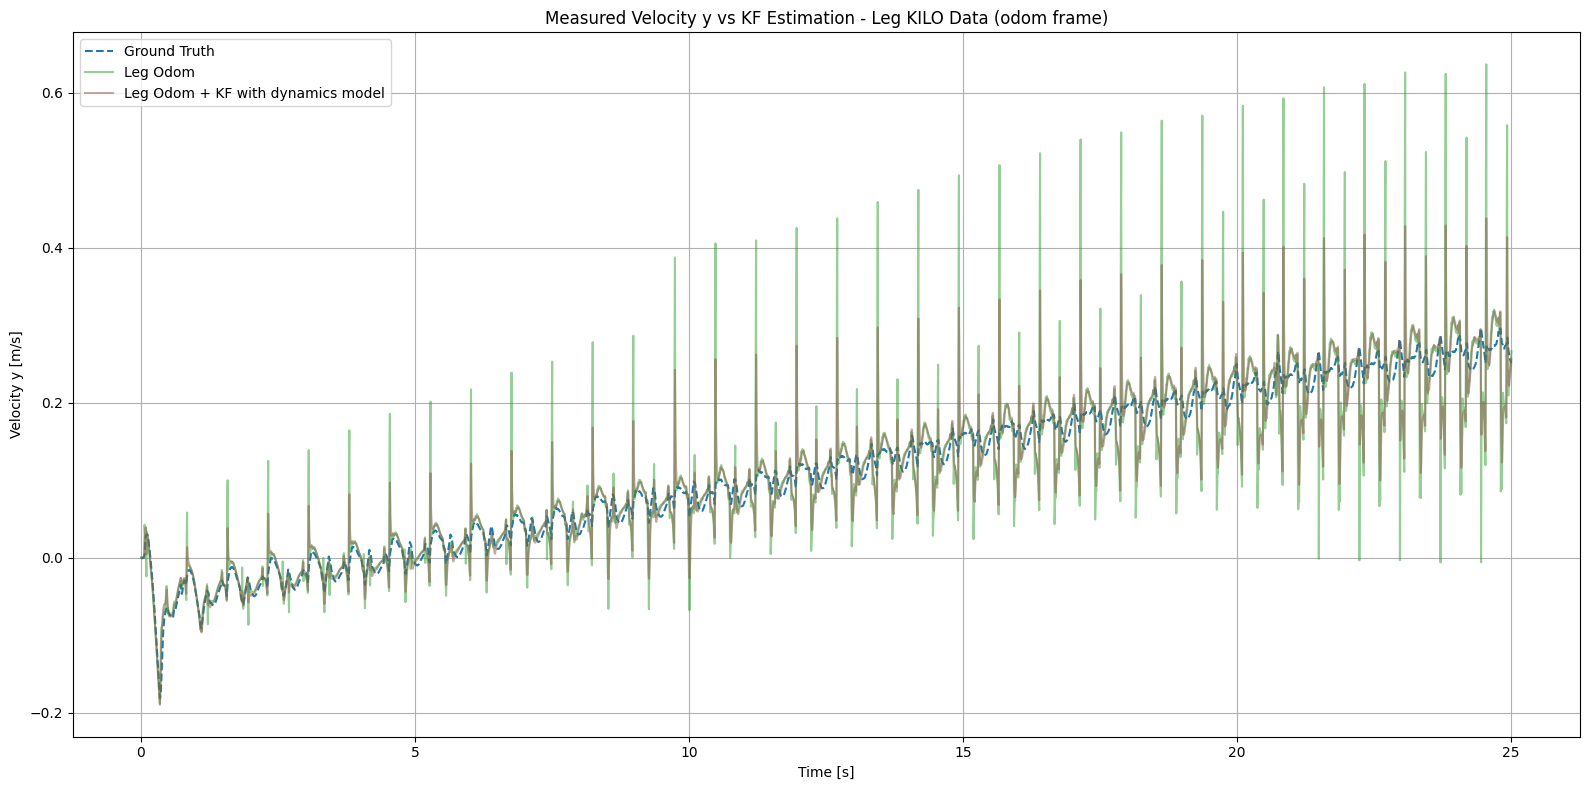

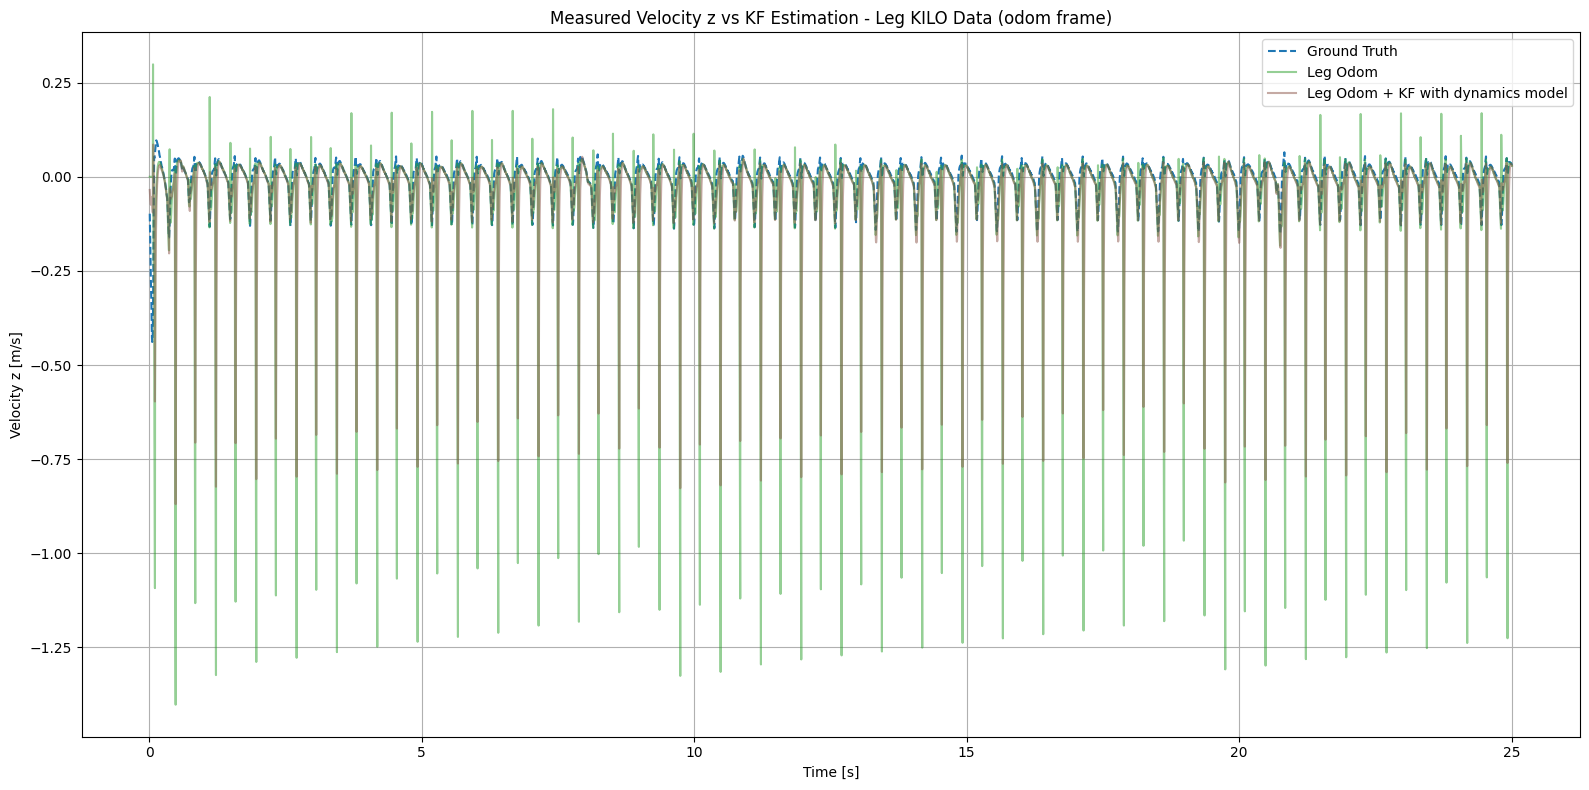

In [33]:
# Odom frame

colors = ['#1f77b4', # gt
        '#2ca02c', # leg odom
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

dim = ["x", "y", "z"]
num_data_points = len(data["dt"])

for i in range(len(dim)):
    gt_values = data["base_vel"][:num_data_points, i:i+1]

    pred_values = [result["leg_odom"][:num_data_points, i:i+1],
                   result["vel_update"][:num_data_points, i:i+1]]

    pred_labels = ["Leg Odom", "Leg Odom + KF with dynamics model"]

    compare_estimation_plot(time=data["time"][:num_data_points],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Leg KILO Data (odom frame)",
                            colors=colors
                            )